Running AdEx multicompartmental microcircuit...
Starting simulation at t=0. s for a duration of 0.5 s
0.5 s (100%) simulated in 2s
Total spikes: 1013


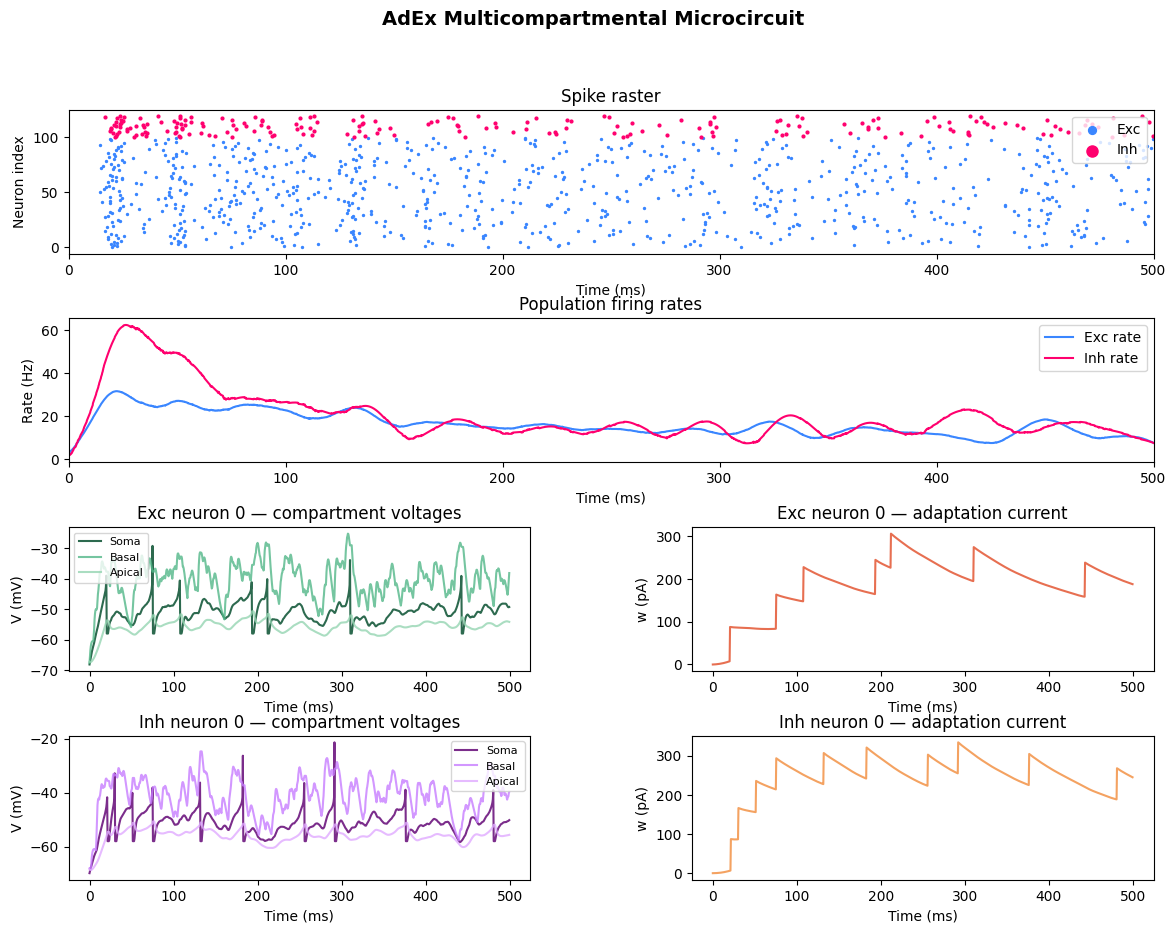

In [4]:
"""
AdEx Multicompartmental Microcircuit — Brian2 Template
=======================================================
Compartments per neuron:
  [0] Basal dendrite
  [1] Soma  (AdEx spike + adaptation here)
  [2] Apical tuft

Coupling:  basal <-> soma <-> apical  (linear cable, axial resistance)

Network:   N_E excitatory + N_I inhibitory neurons
           AMPA, GABA_A synapses; Poisson background input

Usage:
  python adex_multicompartment.py

Requires:  brian2 >= 2.5
"""

from brian2 import *

# ── Simulation settings ────────────────────────────────────────────────────
defaultclock.dt = 0.05 * ms
sim_duration    = 500  * ms
seed(42)

# ── Network size ───────────────────────────────────────────────────────────
N_E = 100  # excitatory neurons
N_I = 20   # inhibitory neurons
N   = N_E + N_I

# ──────────────────────────────────────────────────────────────────────────
#  Shared biophysical parameters
# ──────────────────────────────────────────────────────────────────────────
# Membrane
C_soma   = 200 * pF
C_dend   = 100 * pF   # basal & apical (each)
g_L      = 10  * nS   # leak conductance (soma)
g_L_d    = 5   * nS   # leak conductance (dendrites)
E_L      = -70 * mV   # leak reversal

# AdEx (soma only)
V_T      = -50 * mV   # threshold
delta_T  =  2  * mV   # slope factor
a_sub    =  4  * nS   # subthreshold adaptation
tau_w    = 150 * ms   # adaptation time constant
b_adapt  =  80 * pA   # spike-triggered adaptation increment
V_reset  = -58 * mV
V_peak   =  20 * mV   # spike detection threshold

# Axial coupling (conductances between compartments)
g_ax_bs  = 20  * nS   # basal  <-> soma
g_ax_sa  = 15  * nS   # soma   <-> apical

# Reversal potentials
E_exc    =  0  * mV
E_inh    = -80 * mV

# Synaptic time constants
tau_ampa =  2  * ms
tau_gaba =  5  * ms

# ──────────────────────────────────────────────────────────────────────────
#  Equations
#  We use three voltage variables (V_b, V_s, V_a) in ONE NeuronGroup.
#  Brian2 does not natively support multi-compartment objects, so we
#  implement coupling as explicit current terms.
# ──────────────────────────────────────────────────────────────────────────
eqs = """
# ── Basal dendrite ─────────────────────────────────────────────────────
dV_b/dt = ( -g_L_d*(V_b - E_L)
            + g_ax_bs*(V_s - V_b)   # coupling to soma
            + I_syn_b               # synaptic input to basal
          ) / C_dend  : volt (unless refractory)

I_syn_b = g_ampa_b*(E_exc - V_b) + g_gaba_b*(E_inh - V_b)  : amp
dg_ampa_b/dt = -g_ampa_b / tau_ampa  : siemens
dg_gaba_b/dt = -g_gaba_b / tau_gaba  : siemens

# ── Soma (AdEx) ─────────────────────────────────────────────────────────
dV_s/dt = ( -g_L*(V_s - E_L)
            + g_L*delta_T*exp((V_s - V_T)/delta_T)  # exponential drive
            - w                                       # adaptation current
            + g_ax_bs*(V_b - V_s)                   # from basal
            + g_ax_sa*(V_a - V_s)                   # from apical
            + I_syn_s                                # synaptic @ soma
            + I_ext                                  # injected current
          ) / C_soma  : volt (unless refractory)

dw/dt = ( a_sub*(V_s - E_L) - w ) / tau_w  : amp

I_syn_s = g_ampa_s*(E_exc - V_s) + g_gaba_s*(E_inh - V_s)  : amp
dg_ampa_s/dt = -g_ampa_s / tau_ampa  : siemens
dg_gaba_s/dt = -g_gaba_s / tau_gaba  : siemens

I_ext  : amp   # per-neuron injected current (set externally)

# ── Apical tuft ─────────────────────────────────────────────────────────
dV_a/dt = ( -g_L_d*(V_a - E_L)
            + g_ax_sa*(V_s - V_a)   # coupling to soma
            + I_syn_a               # synaptic input to apical
          ) / C_dend  : volt (unless refractory)

I_syn_a = g_ampa_a*(E_exc - V_a) + g_gaba_a*(E_inh - V_a)  : amp
dg_ampa_a/dt = -g_ampa_a / tau_ampa  : siemens
dg_gaba_a/dt = -g_gaba_a / tau_gaba  : siemens
"""

# ──────────────────────────────────────────────────────────────────────────
#  NeuronGroup
# ──────────────────────────────────────────────────────────────────────────
neurons = NeuronGroup(
    N,
    eqs,
    threshold  = "V_s > V_peak",
    reset      = "V_s = V_reset; w += b_adapt",
    refractory = 2 * ms,
    method     = "exponential_euler",
    namespace  = {
        "C_soma": C_soma, "C_dend": C_dend,
        "g_L": g_L, "g_L_d": g_L_d, "E_L": E_L,
        "V_T": V_T, "delta_T": delta_T,
        "a_sub": a_sub, "tau_w": tau_w, "b_adapt": b_adapt,
        "V_reset": V_reset, "V_peak": V_peak,
        "g_ax_bs": g_ax_bs, "g_ax_sa": g_ax_sa,
        "E_exc": E_exc, "E_inh": E_inh,
        "tau_ampa": tau_ampa, "tau_gaba": tau_gaba,
    },
)

# Excitatory / inhibitory subgroups
exc = neurons[:N_E]
inh = neurons[N_E:]

# Initial conditions
neurons.V_s = E_L + rand(N) * 5 * mV
neurons.V_b = E_L + rand(N) * 3 * mV
neurons.V_a = E_L + rand(N) * 3 * mV
neurons.w   = 0  * pA

# Injected current (override per neuron as needed)
exc.I_ext   = 300 * pA   # drive excitatory population
inh.I_ext   = 250 * pA

# ──────────────────────────────────────────────────────────────────────────
#  Synapses  (recurrent E→E, E→I, I→E, I→I)
# ──────────────────────────────────────────────────────────────────────────
# AMPA: E→E (onto soma)
syn_EE = Synapses(exc, exc,
                  on_pre="g_ampa_s_post += 0.5*nS",
                  delay=1*ms)
syn_EE.connect(condition="i != j", p=0.3)

# AMPA: E→I (onto soma)
syn_EI = Synapses(exc, inh,
                  on_pre="g_ampa_s_post += 1.0*nS",
                  delay=1*ms)
syn_EI.connect(p=0.5)

# GABA: I→E (onto soma)
syn_IE = Synapses(inh, exc,
                  on_pre="g_gaba_s_post += 2.0*nS",
                  delay=1*ms)
syn_IE.connect(p=0.5)

# GABA: I→I (onto soma)
syn_II = Synapses(inh, inh,
                  on_pre="g_gaba_s_post += 1.0*nS",
                  delay=1*ms)
syn_II.connect(condition="i != j", p=0.4)

# ──────────────────────────────────────────────────────────────────────────
#  Poisson background input  (onto basal dendrites)
# ──────────────────────────────────────────────────────────────────────────
poisson_exc = PoissonInput(neurons, "g_ampa_b",
                           N=100, rate=5*Hz, weight=10*nS)
poisson_inh = PoissonInput(neurons, "g_gaba_b",
                           N=20,  rate=5*Hz, weight=0.2*nS)

# ──────────────────────────────────────────────────────────────────────────
#  Monitors
# ──────────────────────────────────────────────────────────────────────────
spike_mon = SpikeMonitor(neurons)

state_mon = StateMonitor(
    neurons,
    variables=["V_s", "V_b", "V_a", "w"],
    record=[0, N_E],   # record neuron 0 (exc) and first inh neuron
    dt=0.5 * ms,
)

rate_mon_exc = PopulationRateMonitor(exc)
rate_mon_inh = PopulationRateMonitor(inh)

# ──────────────────────────────────────────────────────────────────────────
#  Run
# ──────────────────────────────────────────────────────────────────────────
print("Running AdEx multicompartmental microcircuit...")
run(sim_duration, report="stdout")
print(f"Total spikes: {spike_mon.num_spikes}")

# ──────────────────────────────────────────────────────────────────────────
#  Plot results
# ──────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 10))
fig.suptitle("AdEx Multicompartmental Microcircuit", fontsize=14, fontweight="bold")
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

t = state_mon.t / ms

# ── Raster plot ──────────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :])
exc_mask = spike_mon.i < N_E
inh_mask = ~exc_mask
ax0.scatter(spike_mon.t[exc_mask] / ms, spike_mon.i[exc_mask],
            s=2, c="#3A86FF", label="Exc", rasterized=True)
ax0.scatter(spike_mon.t[inh_mask] / ms, spike_mon.i[inh_mask],
            s=4, c="#FF006E", label="Inh", rasterized=True)
ax0.set(xlabel="Time (ms)", ylabel="Neuron index", title="Spike raster")
ax0.legend(loc="upper right", markerscale=4)
ax0.set_xlim(0, sim_duration / ms)

# ── Population firing rates ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(rate_mon_exc.t / ms,
         rate_mon_exc.smooth_rate(window="gaussian", width=10*ms) / Hz,
         color="#3A86FF", label="Exc rate")
ax1.plot(rate_mon_inh.t / ms,
         rate_mon_inh.smooth_rate(window="gaussian", width=10*ms) / Hz,
         color="#FF006E", label="Inh rate")
ax1.set(xlabel="Time (ms)", ylabel="Rate (Hz)", title="Population firing rates")
ax1.legend()
ax1.set_xlim(0, sim_duration / ms)

# ── Compartment voltages — excitatory neuron 0 ───────────────────────────
ax2 = fig.add_subplot(gs[2, 0])
ax2.plot(t, state_mon.V_s[0] / mV, label="Soma",   color="#2D6A4F")
ax2.plot(t, state_mon.V_b[0] / mV, label="Basal",  color="#52B788", alpha=0.8)
ax2.plot(t, state_mon.V_a[0] / mV, label="Apical", color="#95D5B2", alpha=0.8)
ax2.set(xlabel="Time (ms)", ylabel="V (mV)",
        title="Exc neuron 0 — compartment voltages")
ax2.legend(fontsize=8)

# ── Adaptation current — neuron 0 ────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 1])
ax3.plot(t, state_mon.w[0] / pA, color="#E76F51")
ax3.set(xlabel="Time (ms)", ylabel="w (pA)",
        title="Exc neuron 0 — adaptation current")

# ── Compartment voltages — inhibitory neuron (first) ─────────────────────
ax4 = fig.add_subplot(gs[3, 0])
ax4.plot(t, state_mon.V_s[1] / mV, label="Soma",   color="#7B2D8B")
ax4.plot(t, state_mon.V_b[1] / mV, label="Basal",  color="#C77DFF", alpha=0.8)
ax4.plot(t, state_mon.V_a[1] / mV, label="Apical", color="#E0AAFF", alpha=0.8)
ax4.set(xlabel="Time (ms)", ylabel="V (mV)",
        title="Inh neuron 0 — compartment voltages")
ax4.legend(fontsize=8)

# ── Adaptation current — inhibitory neuron ───────────────────────────────
ax5 = fig.add_subplot(gs[3, 1])
ax5.plot(t, state_mon.w[1] / pA, color="#F4A261")
ax5.set(xlabel="Time (ms)", ylabel="w (pA)",
        title="Inh neuron 0 — adaptation current")


plt.show()